In [102]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [103]:
class SharkFluorescenceDataset(Dataset):
    def __init__(self, csv_file, augment=False):
        """
        Args:
            csv_file (string): Path to the csv file with shark data
            augment (bool): Whether to apply data augmentation
        """
        self.data = pd.read_csv(csv_file)
        self.augment = augment
        
        # Separate features and labels
        self.species = self.data['Species'].values
        self.features = self.data.drop('Species', axis=1).values
        
        # Encode labels
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.species)
        
        # Compute normalization statistics from entire dataset
        self.mean = self.features.mean()
        self.std = self.features.std()
        
        print(f"Dataset initialized: {len(self)} samples")
        print(f"Number of species: {len(self.label_encoder.classes_)}")
        print(f"Feature shape: {self.features.shape[1]} time points")
        print(f"Augmentation: {'ON' if augment else 'OFF'}")
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Get sample
        x = self.features[idx].astype(np.float32)  # Ensure float32
        y = self.labels[idx]
        
        # Normalize
        x = (x - self.mean) / self.std
        x = x.astype(np.float32)  # Ensure still float32 after normalization
        
        # Apply augmentation if enabled
        if self.augment:
            x = self._augment(x)
        
        # Reshape to (channels, sequence_length) for 1D Conv
        x = x.reshape(1, -1)  # (1, 3475)
        
        return torch.from_numpy(x).float(), torch.tensor(y, dtype=torch.long)
    
    def _augment(self, x):
        """Apply random augmentations to time series"""
        # Gaussian noise
        if np.random.rand() > 0.5:
            noise = np.random.normal(0, 0.02, x.shape)
            x = x + noise
        
        # Vertical shift (baseline drift)
        if np.random.rand() > 0.5:
            shift = np.random.normal(0, 0.05)
            x = x + shift
        
        # Scaling
        if np.random.rand() > 0.5:
            scale = np.random.uniform(0.95, 1.05)
            x = x * scale
        
        return x

In [104]:
dataset = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=False)

# Split dataset: 70% train, 15% val, 15% test
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\nDataset Split:")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Get class names and number
num_classes = len(dataset.label_encoder.classes_)
class_names = dataset.label_encoder.classes_
print(f"\nSpecies to classify: {num_classes}")

Dataset initialized: 651 samples
Number of species: 57
Feature shape: 3475 time points
Augmentation: OFF

Dataset Split:
Train samples: 455
Validation samples: 97
Test samples: 99

Species to classify: 57


In [105]:
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batches per epoch - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Batches per epoch - Train: 29, Val: 7, Test: 7


In [106]:
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super(TemporalBlock, self).__init__()
        
        padding = (kernel_size - 1) * dilation
        
        # First conv layer
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                               padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.dropout1 = nn.Dropout(dropout)
        
        # Second conv layer
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout2 = nn.Dropout(dropout)
        
        # Residual connection
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Store input for residual
        residual = x
        
        # First conv block
        out = self.conv1(x)
        out = out[:, :, :x.size(2)]  # Causal: remove future timesteps
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout1(out)
        
        # Second conv block
        out = self.conv2(out)
        out = out[:, :, :x.size(2)]  # Causal
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout2(out)
        
        # Residual connection
        if self.downsample is not None:
            residual = self.downsample(residual)
        
        return self.relu(out + residual)

In [107]:
class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, num_classes, kernel_size=5, dropout=0.2):
        """
        TCN Model
        Args:
            num_inputs: Number of input channels (1 for single fluorescence reading)
            num_channels: List of channels for each temporal block
            num_classes: Number of shark species
            kernel_size: Convolution kernel size
            dropout: Dropout probability
        """
        super(TemporalConvNet, self).__init__()
        
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            dilation = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            
            layers.append(TemporalBlock(
                in_channels, out_channels, kernel_size, dilation, dropout
            ))
        
        self.network = nn.Sequential(*layers)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(num_channels[-1], 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        # x shape: (batch, channels, seq_len)
        out = self.network(x)
        out = self.global_pool(out).squeeze(-1)  # (batch, channels)
        out = self.fc(out)
        return out

In [108]:
model = TemporalConvNet(
    num_inputs=1,  # Single fluorescence channel
    num_channels=[32, 32, 64],  # 3 temporal blocks
    num_classes=num_classes,
    kernel_size=5,
    dropout=0.2
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TemporalConvNet(
  (network): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(4,))
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(4,))
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(2,))
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(2,))
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True,

In [109]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [110]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
        
        pbar.set_postfix({'loss': total_loss/(batch_idx+1), 'acc': 100.*correct/total})
    
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
            
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    return total_loss / len(loader), correct / total, all_preds, all_targets


In [111]:
num_epochs = 100
best_val_loss = float('inf')
patience = 15
patience_counter = 0

train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("Starting training...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_tcn_model.pth')
        print("✓ Saved best model")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load('best_tcn_model.pth'))
print("\nLoaded best model for evaluation")

Starting training...

Epoch 1/100


Training: 100%|██████████| 29/29 [00:05<00:00,  5.69it/s, loss=3.98, acc=5.93]


Train Loss: 3.9813, Train Acc: 0.0593
Val Loss: 4.0876, Val Acc: 0.0619
✓ Saved best model

Epoch 2/100


Training: 100%|██████████| 29/29 [00:05<00:00,  5.20it/s, loss=3.84, acc=7.91]


Train Loss: 3.8362, Train Acc: 0.0791
Val Loss: 4.1880, Val Acc: 0.0619

Epoch 3/100


...

Train Loss: 1.5740, Train Acc: 0.4989
Val Loss: 2.8099, Val Acc: 0.3918

Epoch 74/100


Training: 100%|██████████| 29/29 [00:05<00:00,  5.50it/s, loss=1.6, acc=46.8] 


Train Loss: 1.5958, Train Acc: 0.4681
Val Loss: 3.0135, Val Acc: 0.3196

Epoch 75/100


Training: 100%|██████████| 29/29 [00:05<00:00,  5.56it/s, loss=1.61, acc=48.6]


Train Loss: 1.6120, Train Acc: 0.4857
Val Loss: 2.9341, Val Acc: 0.3711

Early stopping at epoch 75

Loaded best model for evaluation


In [112]:
model.load_state_dict(torch.load('best_tcn_shark.pth'))

test_loss, test_acc, test_predictions, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"\n{'='*70}")
print(f"TCN TEST SET RESULTS")
print(f"{'='*70}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"\nClassification Report:")
unique_labels = sorted(list(set(test_labels)))
target_names_test = [full_dataset.label_encoder.classes_[i] for i in unique_labels]
print(classification_report(
    test_labels, 
    test_predictions,
    labels=unique_labels,
    target_names=target_names_test
))

RuntimeError: Error(s) in loading state_dict for TemporalConvNet:
	Missing key(s) in state_dict: "network.0.bn1.weight", "network.0.bn1.bias", "network.0.bn1.running_mean", "network.0.bn1.running_var", "network.0.bn2.weight", "network.0.bn2.bias", "network.0.bn2.running_mean", "network.0.bn2.running_var", "network.1.bn1.weight", "network.1.bn1.bias", "network.1.bn1.running_mean", "network.1.bn1.running_var", "network.1.bn2.weight", "network.1.bn2.bias", "network.1.bn2.running_mean", "network.1.bn2.running_var", "network.2.bn1.weight", "network.2.bn1.bias", "network.2.bn1.running_mean", "network.2.bn1.running_var", "network.2.bn2.weight", "network.2.bn2.bias", "network.2.bn2.running_mean", "network.2.bn2.running_var", "fc.0.weight", "fc.0.bias", "fc.3.weight", "fc.3.bias". 
	Unexpected key(s) in state_dict: "network.3.conv1.weight", "network.3.conv1.bias", "network.3.conv2.weight", "network.3.conv2.bias", "network.3.net.0.weight", "network.3.net.0.bias", "network.3.net.4.weight", "netwo

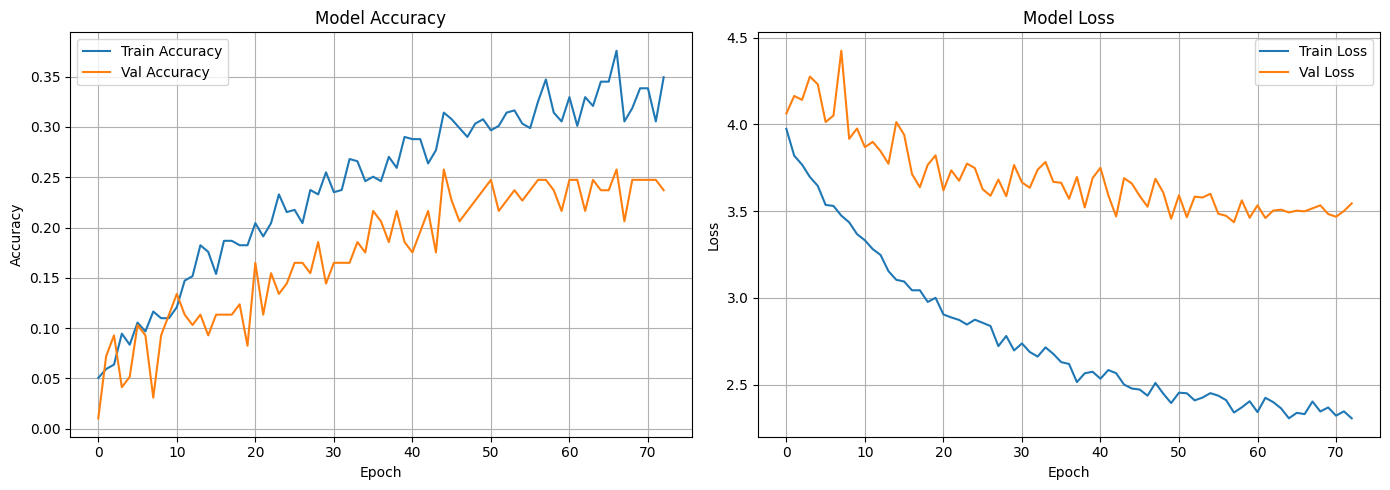

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(train_accs, label='Train Accuracy')
axes[0].plot(val_accs, label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(train_losses, label='Train Loss')
axes[1].plot(val_losses, label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [113]:
test_loss, test_acc, test_preds, test_targets = evaluate(model, test_loader, criterion, device)
print(f"\n{'='*50}")
print(f"TEST SET RESULTS")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")



TEST SET RESULTS
Test Loss: 184.7936
Test Accuracy: 0.0404 (4.04%)


In [ ]:
print("\nClassification Report:")
# Get unique labels that actually appear in test set
unique_test_labels = np.unique(test_targets)
target_names_filtered = [class_names[i] for i in unique_test_labels]

print(classification_report(
    test_targets, 
    test_preds, 
    labels=unique_test_labels,
    target_names=target_names_filtered, 
    zero_division=0
))


Classification Report:


ValueError: Number of classes, 48, does not match size of target_names, 57. Try specifying the labels parameter

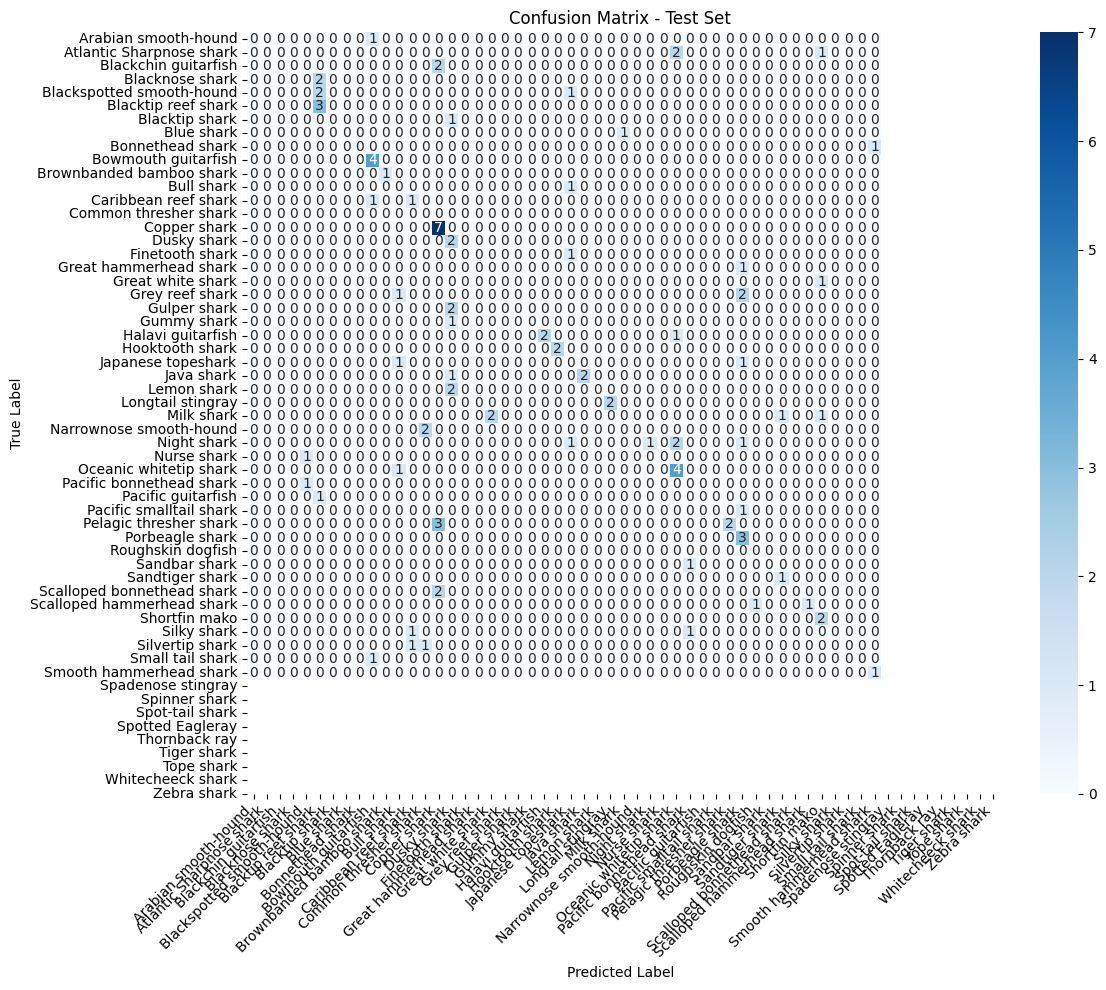

In [64]:
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [65]:
from sklearn.ensemble import RandomForestClassifier

print("\n=== BASELINE: Random Forest ===")
# Get flattened data
X_train_flat = []
y_train_flat = []
for data, target in train_loader:
    X_train_flat.append(data.numpy().reshape(data.size(0), -1))
    y_train_flat.append(target.numpy())
X_train_flat = np.concatenate(X_train_flat, axis=0)
y_train_flat = np.concatenate(y_train_flat, axis=0)

X_test_flat = []
y_test_flat = []
for data, target in test_loader:
    X_test_flat.append(data.numpy().reshape(data.size(0), -1))
    y_test_flat.append(target.numpy())
X_test_flat = np.concatenate(X_test_flat, axis=0)
y_test_flat = np.concatenate(y_test_flat, axis=0)

rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train_flat)
rf_pred = rf.predict(X_test_flat)
rf_acc = accuracy_score(y_test_flat, rf_pred)

print(f"Random Forest test accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"TCN test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\nTCN vs RF difference: {(test_acc - rf_acc)*100:.2f}%")


=== BASELINE: Random Forest ===
Random Forest test accuracy: 0.7980 (79.80%)
TCN test accuracy: 0.4141 (41.41%)

TCN vs RF difference: -38.38%
